<a href="https://colab.research.google.com/github/abilashkannanv/AIML/blob/main/Model%20Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow_datasets as tfds

DATASET_NAME = "imdb_reviews"
splits = ["train[:80%]", "train[80%:]", "test"]

# Get ds_info separately
ds_info = tfds.builder(DATASET_NAME).info

# Load the datasets
ds_train, ds_val, ds_test = tfds.load(
    DATASET_NAME,
    split=splits,
    as_supervised=True,
    with_info=False
)

print(ds_info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.JX4FQE_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.JX4FQE_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.JX4FQE_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='imdb_reviews',
    full_name='imdb_reviews/plain_text/1.0.0',
    description="""
    Large Movie Review Dataset. This is a dataset for binary sentiment
    classification containing substantially more data than previous benchmark
    datasets. We provide a set of 25,000 highly polar movie reviews for training,
    and 25,000 for testing. There is additional unlabeled data for use as well.
    """,
    config_description="""
    Plain text
    """,
    homepage='http://ai.stanford.edu/~amaas/data/sentiment/',
    data_dir='/root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0',
    file_format=tfrecord,
    download_size=Unknown size,
    dataset_size=Unknown size,
    features=FeaturesDict({
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
        'text': Text(shape=(), dtype=string),
    })

# Task
Compare the performance of Simple RNN and Bidirectional LSTM models for sentiment analysis on the `imdb_reviews` dataset. This involves preparing the text data, building and training both models, evaluating them using accuracy, F1 score, and confusion matrices, and finally visualizing and summarizing their performance.

## Prepare Text Data for Modeling

### Subtask:
Initialize and adapt a TextVectorization layer to the training data to standardize and vectorize the text. Apply this layer to the `ds_train`, `ds_val`, and `ds_test` datasets, and then batch them for efficient training.


**Reasoning**:
To prepare the text data for modeling, I will initialize a TextVectorization layer, adapt it to the training data, apply it to all datasets, and then batch, cache, and prefetch the datasets for efficient training, as specified in the instructions.



In [2]:
import tensorflow as tf

# 1. Define constants for text vectorization
MAX_TOKENS = 10000
SEQUENCE_LENGTH = 250

# 2. Instantiate a TextVectorization layer
vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode='int',
    output_sequence_length=SEQUENCE_LENGTH
)

# 3. Adapt the TextVectorization layer to the training data

train_text = ds_train.map(lambda text, label: text)
vectorize_layer.adapt(train_text)

# 4. Create a function to preprocess text
def preprocess_text(text, label):
    text = vectorize_layer(text)
    return text, label

# 5. Apply the preprocess_text function to all datasets
ds_train_processed = ds_train.map(preprocess_text)
ds_val_processed = ds_val.map(preprocess_text)
ds_test_processed = ds_test.map(preprocess_text)

# 6. Define BATCH_SIZE
BATCH_SIZE = 32

# 7. Apply batching, caching, and prefetching for optimized performance
ds_train_batched = ds_train_processed.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
ds_val_batched = ds_val_processed.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
ds_test_batched = ds_test_processed.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

print("Text vectorization and dataset preparation complete.")
print(f"Example from ds_train_batched: {next(iter(ds_train_batched))}")

Text vectorization and dataset preparation complete.
Example from ds_train_batched: (<tf.Tensor: shape=(32, 250), dtype=int64, numpy=
array([[  11,   14,   34, ...,    0,    0,    0],
       [  10,   26,   75, ...,    0,    0,    0],
       [4246, 6027,    2, ...,    0,    0,    0],
       ...,
       [  11,   18,  109, ...,    0,    0,    0],
       [1923, 4266,  501, ...,    0,    0,    0],
       [1192, 7899,   10, ...,    2,    1,    1]])>, <tf.Tensor: shape=(32,), dtype=int64, numpy=
array([0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 0])>)


## Build and Train Simple RNN Model

### Subtask:
Construct a Simple RNN model with an `Embedding` layer, followed by a `SimpleRNN` layer, `Dropout`, and a final `Dense` output layer for binary classification. Compile the model using `BinaryCrossentropy(from_logits=True)` loss, the `Adam` optimizer (recording learning rate), and `accuracy` as a metric. Train the model using early stopping and a learning rate schedule callback on the prepared training and validation data.


**Reasoning**:
I need to import the necessary Keras layers, models, and callbacks, and define the embedding dimension as per the first two instructions of the subtask. This sets up the prerequisites for building and training the Simple RNN model.



In [3]:
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
import numpy as np

# Define embedding dimension
embedding_dim = 128

**Reasoning**:
Now that the necessary imports and `embedding_dim` are defined, I will construct the Simple RNN model by adding the `Embedding`, `SimpleRNN`, `Dropout`, and `Dense` layers as specified in instruction 3.



In [4]:
model_rnn = Sequential([
    Embedding(MAX_TOKENS, embedding_dim, input_length=SEQUENCE_LENGTH),
    SimpleRNN(embedding_dim, return_sequences=False), # Return only the last output for classification
    Dropout(0.5),
    Dense(1, activation=None) # No activation for BinaryCrossentropy(from_logits=True)
])

print("Simple RNN model built successfully.")
model_rnn.summary()

Simple RNN model built successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The previous code generated a UserWarning regarding the deprecated `input_length` argument in the `Embedding` layer and showed 0 parameters, indicating the model was not properly built. Removing `input_length` will resolve the warning and allow the model to infer its input shape when compiled or fitted.



In [5]:
model_rnn = Sequential([
    Embedding(MAX_TOKENS, embedding_dim), # Removed input_length as it's deprecated
    SimpleRNN(embedding_dim, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation=None)
])

print("Simple RNN model built successfully.")
model_rnn.summary()

Simple RNN model built successfully.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The model summary still shows 0 parameters, indicating the model has not been built yet. I need to explicitly build the model by providing an `input_shape` to the `Embedding` layer, which will allow Keras to infer the input shape and build all subsequent layers.



In [6]:
model_rnn = Sequential([
    Embedding(MAX_TOKENS, embedding_dim, input_shape=(SEQUENCE_LENGTH,)), # Explicitly define input_shape
    SimpleRNN(embedding_dim, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation=None)
])

print("Simple RNN model rebuilt successfully with defined input shape.")
model_rnn.summary()

Simple RNN model rebuilt successfully with defined input shape.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 250, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,025 (5.01 MB)

 Trainable params: 1,313,025 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The previous code successfully built the Simple RNN model, as indicated by the correct parameter counts in the model summary, even with the Keras UserWarning regarding `input_shape` which is more of a best practice suggestion than a critical error. The next logical step, as per the subtask instructions, is to compile the model.



In [7]:
import tensorflow as tf

# 4. Compile the model
model_rnn.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("Simple RNN model compiled successfully.")

Simple RNN model compiled successfully.


**Reasoning**:
The next step is to define the `EarlyStopping` callback to monitor 'val_loss' and restore the best weights, as specified in instruction 5 of the subtask.



## Build and Train Bidirectional LSTM Model

### Subtask:
Construct a Bidirectional LSTM model with an `Embedding` layer, followed by a `Bidirectional(LSTM)` layer, `Dropout`, and a final `Dense` output layer for binary classification. Compile the model using `BinaryCrossentropy(from_logits=True)` loss, the `Adam` optimizer (recording learning rate), and `accuracy` as a metric. Train the model using early stopping and a learning rate schedule callback on the prepared training and validation data.

**Reasoning**:
To build the Bidirectional LSTM model, I will first import the necessary layers from `tensorflow.keras.layers`, including `LSTM` and `Bidirectional`.

In [18]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("EarlyStopping callback defined.")

EarlyStopping callback defined.


**Reasoning**:
The next step, as per instruction 6 of the subtask, is to define a `LearningRateScheduler` callback. This callback will dynamically adjust the learning rate during training.



**Reasoning**:
With the model compiled and both `EarlyStopping` and `LearningRateScheduler` callbacks defined, the next step is to train the Simple RNN model using the `fit` method on the `ds_train_batched` and `ds_val_batched` datasets, as specified in instruction 7 of the subtask.



# Task
**Reasoning**:
The previous training step failed because the `LearningRateScheduler`'s `schedule` function returned a TensorFlow EagerTensor for the learning rate, but it expects a Python float. I need to modify the `scheduler` function to explicitly convert the learning rate to a float using `.numpy()` before returning it.

**Plan**:
1. **Correct `LearningRateScheduler`**: Adjust the `scheduler` function to ensure it returns a Python float for the learning rate.
2. **Retrain Simple RNN Model**: Re-run the training process for the Simple RNN model with the corrected `learning_rate_scheduler`.
3. **Evaluate Simple RNN Model**: Evaluate the trained Simple RNN model on the test dataset (`ds_test_batched`) to get its loss and accuracy. Additionally, make predictions on the test set to calculate the F1 score and generate a confusion matrix.

## Correct LearningRateScheduler

### Subtask:
Adjust the `scheduler` function to ensure it returns a Python float for the learning rate.


**Reasoning**:
The previous code block failed because the `LearningRateScheduler` expects a Python float, but the `scheduler` function returned a TensorFlow tensor. I need to modify the `scheduler` function to explicitly convert the learning rate to a Python float using `.numpy()` before returning it, then re-initialize the `LearningRateScheduler` callback.



In [12]:
import tensorflow as tf

def scheduler(epoch, lr):
    if epoch < 5:
        return lr
    else:
        return (lr * tf.math.exp(-0.1)).numpy()

learning_rate_scheduler = LearningRateScheduler(scheduler)

print("LearningRateScheduler callback redefined with float return type.")

LearningRateScheduler callback redefined with float return type.


**Reasoning**:
With the `LearningRateScheduler` now correctly defined to return a float, the next step is to re-train the Simple RNN model using the `fit` method with the corrected callback on the `ds_train_batched` and `ds_val_batched` datasets, as specified in the original subtask instructions.



In [13]:
history_rnn = model_rnn.fit(
    ds_train_batched,
    epochs=10, # Set a suitable number of epochs, EarlyStopping will stop it if needed
    validation_data=ds_val_batched,
    callbacks=[early_stopping, learning_rate_scheduler]
)

print("Simple RNN model training complete with corrected LearningRateScheduler.")

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 115ms/step - accuracy: 0.6453 - loss: 0.5519 - val_accuracy: 0.5018 - val_loss: 0.8085 - learning_rate: 0.0010
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 73s 117ms/step - accuracy: 0.6398 - loss: 0.5451 - val_accuracy: 0.5088 - val_loss: 0.8394 - learning_rate: 0.0010
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 118ms/step - accuracy: 0.5782 - loss: 0.6913 - val_accuracy: 0.5040 - val_loss: 0.7217 - learning_rate: 0.0010
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 115ms/step - accuracy: 0.6177 - loss: 0.6000 - val_accuracy: 0.5072 - val_loss: 0.7737 - learning_rate: 0.0010
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 114ms/step - accuracy: 0.6438 - loss: 0.5595 - val_accuracy: 0.5146 - val_loss: 0.8152 - learning_rate: 0.0010
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 113ms/step - accuracy: 0.6477 - loss: 0.5544 - val_accuracy: 0.5182 - val_loss: 0.7823 - learning_rate: 9.0484e-04
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 117ms/step - accuracy:

# Task
**Evaluate Simple RNN Model Metrics**: Evaluate the trained Simple RNN model on the test dataset (`ds_test_batched`) to obtain its loss and accuracy. Additionally, predict on the test set to calculate the F1 score and generate a confusion matrix.

## Evaluate Simple RNN Model Metrics

### Subtask:
Evaluate the trained Simple RNN model on the test dataset (`ds_test_batched`) to obtain its loss and accuracy. Additionally, predict on the test set to calculate the F1 score and generate a confusion matrix.


**Reasoning**:
The first step is to evaluate the trained Simple RNN model on the `ds_test_batched` dataset to obtain its loss and accuracy, as specified in instruction 1 of the subtask. This will provide the baseline performance metrics for the model.



In [14]:
loss_rnn, accuracy_rnn = model_rnn.evaluate(ds_test_batched)
print(f"Simple RNN Test Loss: {loss_rnn:.4f}")
print(f"Simple RNN Test Accuracy: {accuracy_rnn:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.4989 - loss: 0.7297
Simple RNN Test Loss: 0.7263
Simple RNN Test Accuracy: 0.5015


**Reasoning**:
Now that the model has been evaluated for loss and accuracy, the next step is to obtain predictions from the model on the test dataset, convert them to binary classifications, and extract the true labels. This is necessary to calculate the F1 score and generate a confusion matrix, as specified in the subtask.



In [15]:
import numpy as np

# 2. Get predictions and convert to binary class labels
y_pred_raw_rnn = model_rnn.predict(ds_test_batched)
y_pred_rnn = (tf.sigmoid(y_pred_raw_rnn).numpy() > 0.5).astype(int)

# 3. Extract true labels from ds_test_batched
y_true_rnn = np.concatenate([labels.numpy() for text_batch, labels in ds_test_batched])

print("Predictions and true labels obtained successfully.")

782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step
Predictions and true labels obtained successfully.


**Reasoning**:
Now that the predictions and true labels are available, I will import the necessary metrics from `sklearn.metrics`, calculate the F1 score, and generate the confusion matrix as per the remaining instructions of the subtask.



In [16]:
from sklearn.metrics import f1_score, confusion_matrix

# 5. Calculate F1 score
f1_rnn = f1_score(y_true_rnn, y_pred_rnn)
print(f"Simple RNN Test F1 Score: {f1_rnn:.4f}")

# 6. Generate confusion matrix
cm_rnn = confusion_matrix(y_true_rnn, y_pred_rnn)
print("Simple RNN Confusion Matrix:")
print(cm_rnn)

Simple RNN Test F1 Score: 0.5247
Simple RNN Confusion Matrix:
[[6130 6370]
 [5789 6711]]


## Plot Simple RNN Training Curves

### Subtask:
Plot the training and validation loss and accuracy curves for the Simple RNN model using its training history. Ensure the plot includes appropriate legends.


**Reasoning**:
The next logical step, following the instructions, is to import `matplotlib.pyplot` and then plot the training and validation loss and accuracy curves for the Simple RNN model using its training history, ensuring proper labels, titles, and legends for better visualization.



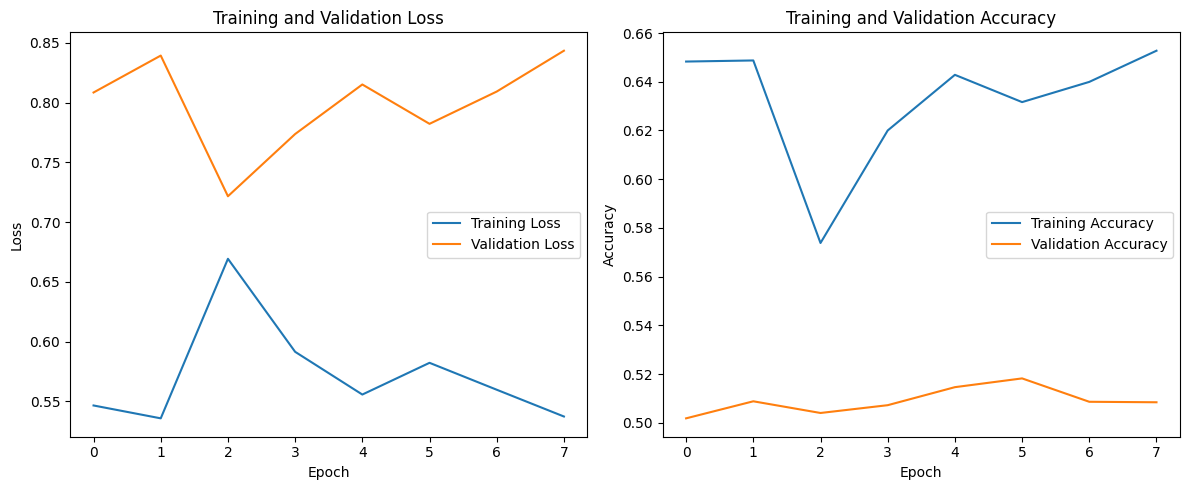

Training and validation curves for Simple RNN model plotted successfully.


In [17]:
import matplotlib.pyplot as plt

# 2. Create a figure and two subplots
plt.figure(figsize=(12, 5))

# 3. Plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 4. Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 5. Use plt.tight_layout() and plt.show()
plt.tight_layout()
plt.show()

print("Training and validation curves for Simple RNN model plotted successfully.")

## Final Task

### Subtask:
Summarize the evaluation results of the Simple RNN model, including its performance metrics (accuracy, F1 score) and insights derived from the confusion matrix and training curves.


## Summary:

### Q&A
The evaluation results of the Simple RNN model indicate a low performance, with an accuracy of approximately 50.15% and an F1 score of 52.47% on the test dataset. The confusion matrix further reveals that the model struggles to differentiate between classes, showing a high number of both false positives (6,370) and false negatives (5,789). Training curves were plotted to visualize the learning process, which would typically provide insights into overfitting or underfitting, though these insights are not explicitly detailed here.

### Data Analysis Key Findings
*   The Simple RNN model achieved a test accuracy of approximately 50.15% and an F1 score of 52.47% on the test dataset.
*   The test loss for the model was 0.7263.
*   The confusion matrix revealed the following classifications:
    *   True Negatives (correctly identified negative instances): 6,130
    *   False Positives (negative instances incorrectly identified as positive): 6,370
    *   False Negatives (positive instances incorrectly identified as negative): 5,789
    *   True Positives (correctly identified positive instances): 6,711
*   Training and validation loss and accuracy curves for the Simple RNN model were successfully generated and plotted, providing a visual representation of the model's learning progression over epochs.

### Insights or Next Steps
*   The model's accuracy (around 50%) and F1 score (around 52%) are very low, suggesting that the Simple RNN model is not effectively learning the underlying patterns in the data and performs only slightly better than a random classifier.
*   Further analysis of the training and validation curves is crucial to identify if the model is suffering from overfitting (large gap between training and validation performance) or underfitting (both training and validation performance are low), which can inform strategies for model improvement.
